In [ ]:
import xarray as xr
import numpy as np
from scipy import stats
import os
import glob
import re
import warnings

warnings.filterwarnings("ignore")


# ============================================================
# CONFIGURATION
# ============================================================

INPUT_FOLDER = (
    r"D:\Project Works\Drought_QLD\Data\SPI\Monthly Rain QLD"
)

OUTPUT_FOLDER = (
    r"D:\Project Works\Drought_QLD\Data\SPI\SPI"
)

# Example input filenames:
# 2000.monthly_rain.nc
# 2001.monthly_rain.nc
# ...
# 2025.monthly_rain.nc
FILE_PATTERN = "*.nc"

# Rainfall variable inside the NetCDF files
VAR_NAME = "monthly_rain"

# Coordinate and dimension names
TIME_NAME = "time"
LAT_NAME = "lat"
LON_NAME = "lon"

# SPI timescales
TIMESCALE_LIST = [1, 3, 6, 12]

# Input and output period
START_YEAR = 2000
END_YEAR = 2025

# Minimum number of observations required for Gamma fitting
MIN_VALID_OBSERVATIONS = 3

# Prevent infinite SPI values
PROBABILITY_LIMIT = 1e-6


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def extract_year_from_filename(filepath):
    """
    Extract a four-digit year from a filename.

    Examples:
        2000.monthly_rain.nc -> 2000
        monthly_rain_2001.nc -> 2001
        rain-2002.nc         -> 2002
    """
    filename = os.path.basename(filepath)

    match = re.search(r"(19|20)\d{2}", filename)

    if match is None:
        return 9999

    return int(match.group())


def find_input_files():
    """
    Find and chronologically sort yearly NetCDF files.
    Only files between START_YEAR and END_YEAR are retained.
    """
    search_path = os.path.join(INPUT_FOLDER, FILE_PATTERN)
    all_files = glob.glob(search_path)

    selected_files = []

    for filepath in all_files:
        year = extract_year_from_filename(filepath)

        if START_YEAR <= year <= END_YEAR:
            selected_files.append(filepath)

    selected_files.sort(key=extract_year_from_filename)

    if not selected_files:
        raise FileNotFoundError(
            f"No NetCDF files were found in:\n{INPUT_FOLDER}\n"
            f"using pattern: {FILE_PATTERN}"
        )

    return selected_files


def compute_spi_gamma(data_array):
    """
    Calculate SPI using a Gamma probability distribution.

    The input is a one-dimensional time series for one grid cell and
    one calendar month.

    For example, when calculating January SPI, this function receives
    all January rolling rainfall values from 2000 to 2025.
    """
    data_array = np.asarray(data_array, dtype=np.float64)

    result = np.full(data_array.shape, np.nan, dtype=np.float64)

    valid_mask = np.isfinite(data_array)
    clean_data = data_array[valid_mask]

    if clean_data.size < MIN_VALID_OBSERVATIONS:
        return result

    # Rainfall should not be negative.
    clean_data = np.where(clean_data < 0, np.nan, clean_data)

    finite_clean_mask = np.isfinite(clean_data)
    clean_data = clean_data[finite_clean_mask]

    if clean_data.size < MIN_VALID_OBSERVATIONS:
        return result

    zero_mask = clean_data == 0
    non_zero_data = clean_data[clean_data > 0]

    total_count = clean_data.size
    zero_count = np.sum(zero_mask)

    # Probability of zero rainfall
    q = zero_count / total_count

    if non_zero_data.size < MIN_VALID_OBSERVATIONS:
        return result

    # Gamma fitting is not possible for a constant series
    if np.nanstd(non_zero_data) == 0:
        return result

    try:
        # Fit Gamma distribution.
        # floc=0 forces the rainfall distribution to begin at zero.
        shape, location, scale = stats.gamma.fit(
            non_zero_data,
            floc=0
        )

        clean_spi = np.full(clean_data.shape, np.nan, dtype=np.float64)

        # For positive rainfall:
        positive_mask = clean_data > 0

        gamma_probability = stats.gamma.cdf(
            clean_data[positive_mask],
            a=shape,
            loc=location,
            scale=scale
        )

        combined_probability = (
            q + (1.0 - q) * gamma_probability
        )

        combined_probability = np.clip(
            combined_probability,
            PROBABILITY_LIMIT,
            1.0 - PROBABILITY_LIMIT
        )

        clean_spi[positive_mask] = stats.norm.ppf(
            combined_probability
        )

        # For zero rainfall, use half of the zero probability.
        # This avoids assigning the upper boundary of the zero interval.
        if np.any(zero_mask):
            zero_probability = np.clip(
                q / 2.0,
                PROBABILITY_LIMIT,
                1.0 - PROBABILITY_LIMIT
            )

            clean_spi[zero_mask] = stats.norm.ppf(
                zero_probability
            )

        # Reconstruct the original array, preserving missing values.
        valid_positions = np.where(valid_mask)[0]
        finite_positions = valid_positions[finite_clean_mask]

        result[finite_positions] = clean_spi

    except (ValueError, RuntimeError, FloatingPointError):
        # Return missing values where Gamma fitting fails.
        return result

    return result


def standardise_coordinates(ds):
    """
    Rename common coordinate alternatives to time, lat, and lon.
    """
    rename_dictionary = {}

    if TIME_NAME not in ds.dims and TIME_NAME not in ds.coords:
        for candidate in ["Time", "TIME", "date", "Date"]:
            if candidate in ds.dims or candidate in ds.coords:
                rename_dictionary[candidate] = TIME_NAME
                break

    if LAT_NAME not in ds.dims and LAT_NAME not in ds.coords:
        for candidate in ["latitude", "Latitude", "LAT", "y"]:
            if candidate in ds.dims or candidate in ds.coords:
                rename_dictionary[candidate] = LAT_NAME
                break

    if LON_NAME not in ds.dims and LON_NAME not in ds.coords:
        for candidate in ["longitude", "Longitude", "LON", "x"]:
            if candidate in ds.dims or candidate in ds.coords:
                rename_dictionary[candidate] = LON_NAME
                break

    if rename_dictionary:
        ds = ds.rename(rename_dictionary)

    return ds


# ============================================================
# MAIN PROCESSING
# ============================================================

def main():

    os.makedirs(OUTPUT_FOLDER, exist_ok=True)

    print("=" * 70)
    print("YEARLY RAINFALL FILES TO SPI")
    print("=" * 70)

    # --------------------------------------------------------
    # 1. Locate yearly files
    # --------------------------------------------------------
    input_files = find_input_files()

    print(f"\n1. Found {len(input_files)} yearly NetCDF files:")

    for filepath in input_files:
        print(f"   {os.path.basename(filepath)}")

    expected_years = set(range(START_YEAR, END_YEAR + 1))

    available_years = {
        extract_year_from_filename(filepath)
        for filepath in input_files
    }

    missing_years = sorted(expected_years - available_years)

    if missing_years:
        print("\nWARNING: The following years are missing:")
        print(missing_years)

    # --------------------------------------------------------
    # 2. Open and combine yearly files
    # --------------------------------------------------------
    print("\n2. Opening and combining yearly files...")

    ds = xr.open_mfdataset(
        input_files,
        combine="by_coords",
        parallel=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={
            LAT_NAME: 50,
            LON_NAME: 50
        }
    )

    ds = standardise_coordinates(ds)

    required_dimensions = [TIME_NAME, LAT_NAME, LON_NAME]

    for dimension in required_dimensions:
        if dimension not in ds.dims and dimension not in ds.coords:
            raise ValueError(
                f"Required coordinate/dimension '{dimension}' was not found.\n"
                f"Available dimensions: {list(ds.dims)}\n"
                f"Available coordinates: {list(ds.coords)}"
            )

    if VAR_NAME not in ds.data_vars:
        raise ValueError(
            f"Variable '{VAR_NAME}' was not found.\n"
            f"Available variables: {list(ds.data_vars)}"
        )

    # Sort chronologically and remove duplicate timestamps if present.
    ds = ds.sortby(TIME_NAME)

    _, unique_time_indices = np.unique(
        ds[TIME_NAME].values,
        return_index=True
    )

    unique_time_indices = np.sort(unique_time_indices)
    ds = ds.isel({TIME_NAME: unique_time_indices})

    print("\nCombined dataset:")
    print(ds)

    print(
        f"\nTime range: "
        f"{str(ds[TIME_NAME].values[0])[:10]} to "
        f"{str(ds[TIME_NAME].values[-1])[:10]}"
    )

    print(f"Number of time steps: {ds.sizes[TIME_NAME]}")

    # --------------------------------------------------------
    # 3. Select rainfall period
    # --------------------------------------------------------
    rainfall = ds[VAR_NAME].sel(
        {
            TIME_NAME: slice(
                f"{START_YEAR}-01-01",
                f"{END_YEAR}-12-31"
            )
        }
    )

    # Ensure dimensions are in a predictable order.
    rainfall = rainfall.transpose(
        TIME_NAME,
        LAT_NAME,
        LON_NAME
    )

    # The downloaded files already contain monthly rainfall.
    # Therefore, no daily-to-monthly resampling is normally required.
    #
    # We use resample only to create a regular monthly timeline and to
    # handle any duplicate or irregular monthly timestamps.
    rainfall_monthly = rainfall.resample(
        {TIME_NAME: "MS"}
    ).sum(
        skipna=False,
        min_count=1
    )

    # SPI calculations require the complete time series to be available
    # within one Dask chunk.
    rainfall_monthly = rainfall_monthly.chunk(
        {
            TIME_NAME: -1,
            LAT_NAME: 50,
            LON_NAME: 50
        }
    )

    print("\n3. Monthly rainfall prepared.")
    print(f"Monthly time steps: {rainfall_monthly.sizes[TIME_NAME]}")

    expected_months = (
        END_YEAR - START_YEAR + 1
    ) * 12

    if rainfall_monthly.sizes[TIME_NAME] != expected_months:
        print(
            f"WARNING: Expected {expected_months} months, but found "
            f"{rainfall_monthly.sizes[TIME_NAME]} months."
        )

    # --------------------------------------------------------
    # 4. Calculate SPI
    # --------------------------------------------------------
    spi_variables = {}

    for scale in TIMESCALE_LIST:

        print(f"\n4. Calculating SPI-{scale}...")

        rolling_rainfall = rainfall_monthly.rolling(
            {TIME_NAME: scale},
            center=False,
            min_periods=scale
        ).sum(
            skipna=False
        )

        # Fit each calendar month separately.
        # January values are compared with January values,
        # February with February, and so on.
        spi = rolling_rainfall.groupby(
            f"{TIME_NAME}.month"
        ).map(
            lambda monthly_group: xr.apply_ufunc(
                compute_spi_gamma,
                monthly_group,
                input_core_dims=[[TIME_NAME]],
                output_core_dims=[[TIME_NAME]],
                vectorize=True,
                dask="parallelized",
                output_dtypes=[np.float32],
                dask_gufunc_kwargs={
                    "allow_rechunk": True
                }
            )
        )

        spi = spi.sortby(TIME_NAME)

        variable_name = f"spi_scale{scale}"

        spi.name = variable_name

        spi.attrs = {
            "long_name": (
                f"Standardized Precipitation Index "
                f"at {scale}-month timescale"
            ),
            "standard_name": (
                f"standardized_precipitation_index_{scale}_month"
            ),
            "units": "1",
            "timescale_months": scale,
            "distribution": "Gamma",
            "calibration_start_year": START_YEAR,
            "calibration_end_year": END_YEAR,
            "description": (
                f"SPI-{scale} calculated by fitting a Gamma "
                "distribution separately for each calendar month."
            )
        }

        spi_variables[variable_name] = spi.astype(np.float32)

    ds_spi = xr.Dataset(spi_variables)

    # Add global metadata.
    ds_spi.attrs = {
        "title": "Queensland Standardized Precipitation Index",
        "description": (
            "SPI-1, SPI-3, SPI-6 and SPI-12 calculated from "
            "monthly rainfall data."
        ),
        "input_period": f"{START_YEAR}-{END_YEAR}",
        "distribution": "Gamma",
        "software": "Python, xarray, NumPy and SciPy"
    }

    # --------------------------------------------------------
    # 5. Save one NetCDF file per year
    # --------------------------------------------------------
    print("\n5. Saving year-wise SPI files...")

    for year in range(START_YEAR, END_YEAR + 1):

        year_start = f"{year}-01-01"
        year_end = f"{year}-12-31"

        ds_year = ds_spi.sel(
            {
                TIME_NAME: slice(year_start, year_end)
            }
        )

        if ds_year.sizes.get(TIME_NAME, 0) == 0:
            print(f"   Skipping {year}: no data found.")
            continue

        output_filename = f"QLD_SPI_{year}.nc"
        output_path = os.path.join(
            OUTPUT_FOLDER,
            output_filename
        )

        encoding = {}

        for variable_name in ds_year.data_vars:
            encoding[variable_name] = {
                "dtype": "float32",
                "zlib": True,
                "complevel": 4,
                "_FillValue": np.float32(-9999.0)
            }

        print(
            f"   Writing {output_filename} "
            f"({ds_year.sizes[TIME_NAME]} months)..."
        )

        ds_year.to_netcdf(
            output_path,
            mode="w",
            format="NETCDF4",
            encoding=encoding
        )

    ds.close()

    print("\n" + "=" * 70)
    print("SPI CALCULATION COMPLETED")
    print(f"Output folder:\n{OUTPUT_FOLDER}")
    print("=" * 70)


if __name__ == "__main__":
    main()

In [2]:
import xarray as xr
import numpy as np
from scipy import stats
import os
import glob
import re
import warnings

warnings.filterwarnings("ignore")


# ============================================================
# CONFIGURATION
# ============================================================

INPUT_FOLDER = r"D:\Project Works\Drought_QLD\Data\SPI\Monthly Rain QLD"
OUTPUT_FOLDER = r"D:\Project Works\Drought_QLD\Data\SPI\SPI"

VAR_NAME = "monthly_rain"
FILE_PATTERN = "*.nc"

TIME_NAME = "time"
LAT_NAME = "lat"
LON_NAME = "lon"

TIMESCALE_LIST = [1, 3, 6, 12]

START_YEAR_OUTPUT = 2000
END_YEAR_OUTPUT = 2025

# Increase or decrease depending on your computer memory.
# Try 100 first. If RAM is sufficient, try 150 or 200.
SPATIAL_CHUNK_SIZE = 100


# ============================================================
# FILE HANDLING
# ============================================================

def extract_year(filepath):
    """
    Extract year from filenames such as:
    2000.monthly_rain.nc
    monthly_rain_2000.nc
    """
    filename = os.path.basename(filepath)
    match = re.search(r"(19|20)\d{2}", filename)

    if match:
        return int(match.group())

    return 9999


def get_input_files():
    """
    Find and sort files from 2000 to 2025.
    """
    files = glob.glob(
        os.path.join(INPUT_FOLDER, FILE_PATTERN)
    )

    files = [
        file for file in files
        if START_YEAR_OUTPUT <= extract_year(file) <= END_YEAR_OUTPUT
    ]

    files.sort(key=extract_year)

    if not files:
        raise FileNotFoundError(
            f"No NetCDF files found in:\n{INPUT_FOLDER}"
        )

    return files


# ============================================================
# SPI CALCULATION
# ============================================================

def rolling_sum_1d(values, scale):
    """
    Calculate backward-looking rolling rainfall totals.

    This matches:
        xarray.rolling(time=scale, min_periods=scale).sum()
    """
    values = np.asarray(values, dtype=np.float64)

    result = np.full(values.shape, np.nan, dtype=np.float64)

    if scale == 1:
        return values.copy()

    valid_values = np.where(
        np.isfinite(values),
        values,
        0.0
    )

    cumulative_sum = np.concatenate(
        ([0.0], np.cumsum(valid_values))
    )

    rolling_values = (
        cumulative_sum[scale:]
        - cumulative_sum[:-scale]
    )

    # Require every value in the rolling window to be valid.
    valid_integer = np.isfinite(values).astype(np.int16)

    cumulative_valid = np.concatenate(
        ([0], np.cumsum(valid_integer))
    )

    valid_counts = (
        cumulative_valid[scale:]
        - cumulative_valid[:-scale]
    )

    rolling_values[valid_counts < scale] = np.nan

    result[scale - 1:] = rolling_values

    return result


def compute_spi_gamma_original(data_array):
    """
    Original SPI Gamma calculation.

    This keeps the mathematical method from the user's original code:
        1. Fit Gamma to positive rainfall
        2. Include probability of zero rainfall
        3. Convert cumulative probability to standard normal
    """
    data_array = np.asarray(data_array, dtype=np.float64)

    result = np.full(
        data_array.shape,
        np.nan,
        dtype=np.float64
    )

    valid_mask = np.isfinite(data_array)
    clean_data = data_array[valid_mask]

    if len(clean_data) < 3:
        return result

    zeros = clean_data == 0
    non_zeros = clean_data[clean_data > 0]

    number_of_values = len(clean_data)
    number_of_zeros = np.sum(zeros)

    q = number_of_zeros / number_of_values

    if len(non_zeros) == 0:
        result[valid_mask] = stats.norm.ppf(q)
        return result

    try:
        alpha, location, beta = stats.gamma.fit(
            non_zeros,
            floc=0
        )

        gamma_probability = stats.gamma.cdf(
            clean_data,
            alpha,
            loc=location,
            scale=beta
        )

        cumulative_probability = (
            q + (1.0 - q) * gamma_probability
        )

        cumulative_probability = np.clip(
            cumulative_probability,
            0,
            0.99999
        )

        spi_values = stats.norm.ppf(
            cumulative_probability
        )

        result[valid_mask] = spi_values

    except (ValueError, RuntimeError, FloatingPointError):
        return result

    return result


def compute_spi_pixel(
    rainfall_series,
    month_numbers,
    scale
):
    """
    Calculate one SPI scale for one complete grid-cell time series.

    This function is called only once per grid cell per scale,
    rather than once for each calendar month.
    """
    rainfall_series = np.asarray(
        rainfall_series,
        dtype=np.float64
    )

    month_numbers = np.asarray(
        month_numbers,
        dtype=np.int16
    )

    accumulated_rainfall = rolling_sum_1d(
        rainfall_series,
        scale
    )

    spi_result = np.full(
        accumulated_rainfall.shape,
        np.nan,
        dtype=np.float64
    )

    # Fit Januaries with Januaries, Februaries with Februaries, etc.
    for calendar_month in range(1, 13):

        month_mask = month_numbers == calendar_month

        monthly_values = accumulated_rainfall[month_mask]

        monthly_spi = compute_spi_gamma_original(
            monthly_values
        )

        spi_result[month_mask] = monthly_spi

    return spi_result.astype(np.float32)


# ============================================================
# MAIN
# ============================================================

def main():

    os.makedirs(
        OUTPUT_FOLDER,
        exist_ok=True
    )

    print("=" * 65)
    print("OPTIMISED SPI CALCULATION")
    print("=" * 65)

    # --------------------------------------------------------
    # 1. Find files
    # --------------------------------------------------------

    input_files = get_input_files()

    print(f"\n1. Found {len(input_files)} files.")

    for file in input_files:
        print(f"   {os.path.basename(file)}")

    # --------------------------------------------------------
    # 2. Open yearly files
    # --------------------------------------------------------

    print("\n2. Opening files...")

    ds = xr.open_mfdataset(
        input_files,
        combine="by_coords",
        data_vars="minimal",
        coords="minimal",
        compat="override",
        parallel=False,
        chunks={
            TIME_NAME: -1,
            LAT_NAME: SPATIAL_CHUNK_SIZE,
            LON_NAME: SPATIAL_CHUNK_SIZE
        }
    )

    if VAR_NAME not in ds.data_vars:
        raise ValueError(
            f"Variable '{VAR_NAME}' not found.\n"
            f"Available variables: {list(ds.data_vars)}"
        )

    rainfall = ds[VAR_NAME].sortby(TIME_NAME)

    rainfall = rainfall.sel(
        {
            TIME_NAME: slice(
                f"{START_YEAR_OUTPUT}-01-01",
                f"{END_YEAR_OUTPUT}-12-31"
            )
        }
    )

    # Remove duplicate time coordinates.
    _, unique_indices = np.unique(
        rainfall[TIME_NAME].values,
        return_index=True
    )

    rainfall = rainfall.isel(
        {
            TIME_NAME: np.sort(unique_indices)
        }
    )

    rainfall = rainfall.transpose(
        TIME_NAME,
        LAT_NAME,
        LON_NAME
    )

    # Your files already contain monthly rainfall.
    # Therefore, monthly resampling is not performed.
    rainfall = rainfall.chunk(
        {
            TIME_NAME: -1,
            LAT_NAME: SPATIAL_CHUNK_SIZE,
            LON_NAME: SPATIAL_CHUNK_SIZE
        }
    )

    month_numbers = xr.DataArray(
        rainfall[TIME_NAME].dt.month.values.astype(np.int16),
        dims=[TIME_NAME],
        coords={
            TIME_NAME: rainfall[TIME_NAME]
        }
    )

    print(f"   Time steps: {rainfall.sizes[TIME_NAME]}")
    print(f"   Latitude cells: {rainfall.sizes[LAT_NAME]}")
    print(f"   Longitude cells: {rainfall.sizes[LON_NAME]}")

    # --------------------------------------------------------
    # 3. Calculate and save each SPI scale separately
    # --------------------------------------------------------

    for scale in TIMESCALE_LIST:

        print(f"\n3. Calculating SPI-{scale}...")

        spi = xr.apply_ufunc(
            compute_spi_pixel,
            rainfall,
            month_numbers,
            input_core_dims=[
                [TIME_NAME],
                [TIME_NAME]
            ],
            output_core_dims=[
                [TIME_NAME]
            ],
            kwargs={
                "scale": scale
            },
            vectorize=True,
            dask="parallelized",
            output_dtypes=[np.float32],
            dask_gufunc_kwargs={
                "allow_rechunk": True,
                "output_sizes": {
                    TIME_NAME: rainfall.sizes[TIME_NAME]
                }
            }
        )

        # apply_ufunc normally places the core dimension last.
        spi = spi.transpose(
            TIME_NAME,
            LAT_NAME,
            LON_NAME
        )

        variable_name = f"spi_scale{scale}"
        spi.name = variable_name

        spi.attrs = {
            "long_name": (
                f"Standardized Precipitation Index "
                f"at {scale}-month timescale"
            ),
            "units": "1",
            "timescale_months": scale,
            "distribution": "Gamma",
            "calibration_period": (
                f"{START_YEAR_OUTPUT}-{END_YEAR_OUTPUT}"
            )
        }

        # ----------------------------------------------------
        # Save one file per year for the current scale
        # ----------------------------------------------------

        for year in range(
            START_YEAR_OUTPUT,
            END_YEAR_OUTPUT + 1
        ):

            yearly_spi = spi.sel(
                {
                    TIME_NAME: slice(
                        f"{year}-01-01",
                        f"{year}-12-31"
                    )
                }
            ).to_dataset(name=variable_name)

            if yearly_spi.sizes.get(TIME_NAME, 0) == 0:
                continue

            output_filename = (
                f"QLD_SPI{scale}_{year}.nc"
            )

            output_path = os.path.join(
                OUTPUT_FOLDER,
                output_filename
            )

            encoding = {
                variable_name: {
                    "dtype": "float32",
                    "zlib": True,
                    "complevel": 2,
                    "_FillValue": np.float32(-9999.0)
                }
            }

            print(f"   Writing {output_filename}...")

            yearly_spi.to_netcdf(
                output_path,
                engine="netcdf4",
                encoding=encoding
            )

        # Delete the scale before processing the next one.
        # This reduces memory consumption.
        del spi

    ds.close()

    print("\n" + "=" * 65)
    print("COMPLETED")
    print(f"Output folder: {OUTPUT_FOLDER}")
    print("=" * 65)


if __name__ == "__main__":
    main()

OPTIMISED SPI CALCULATION

1. Found 26 files.
   QLD_2000.monthly_rain.nc
   QLD_2001.monthly_rain.nc
   QLD_2002.monthly_rain.nc
   QLD_2003.monthly_rain.nc
   QLD_2004.monthly_rain.nc
   QLD_2005.monthly_rain.nc
   QLD_2006.monthly_rain.nc
   QLD_2007.monthly_rain.nc
   QLD_2008.monthly_rain.nc
   QLD_2009.monthly_rain.nc
   QLD_2010.monthly_rain.nc
   QLD_2011.monthly_rain.nc
   QLD_2012.monthly_rain.nc
   QLD_2013.monthly_rain.nc
   QLD_2014.monthly_rain.nc
   QLD_2015.monthly_rain.nc
   QLD_2016.monthly_rain.nc
   QLD_2017.monthly_rain.nc
   QLD_2018.monthly_rain.nc
   QLD_2019.monthly_rain.nc
   QLD_2020.monthly_rain.nc
   QLD_2021.monthly_rain.nc
   QLD_2022.monthly_rain.nc
   QLD_2023.monthly_rain.nc
   QLD_2024.monthly_rain.nc
   QLD_2025.monthly_rain.nc

2. Opening files...
   Time steps: 312
   Latitude cells: 382
   Longitude cells: 311

3. Calculating SPI-1...
   Writing QLD_SPI1_2000.nc...
   Writing QLD_SPI1_2001.nc...
   Writing QLD_SPI1_2002.nc...
   Writing QLD_SPI1_2

In [2]:
import xarray as xr
df = xr.open_dataset(r'D:\Project Works\Drought_QLD\Data\SPI\SPI\QLD_SPI1_2000.nc')
print(df)

<xarray.Dataset> Size: 6MB
Dimensions:     (time: 12, lat: 382, lon: 311)
Coordinates:
  * time        (time) datetime64[ns] 96B 2000-01-16T12:00:00 ... 2000-12-16T...
  * lat         (lat) float64 3kB -29.15 -29.1 -29.05 ... -10.2 -10.15 -10.1
  * lon         (lon) float64 2kB 138.0 138.1 138.1 138.2 ... 153.4 153.4 153.5
Data variables:
    spi_scale1  (time, lat, lon) float32 6MB ...


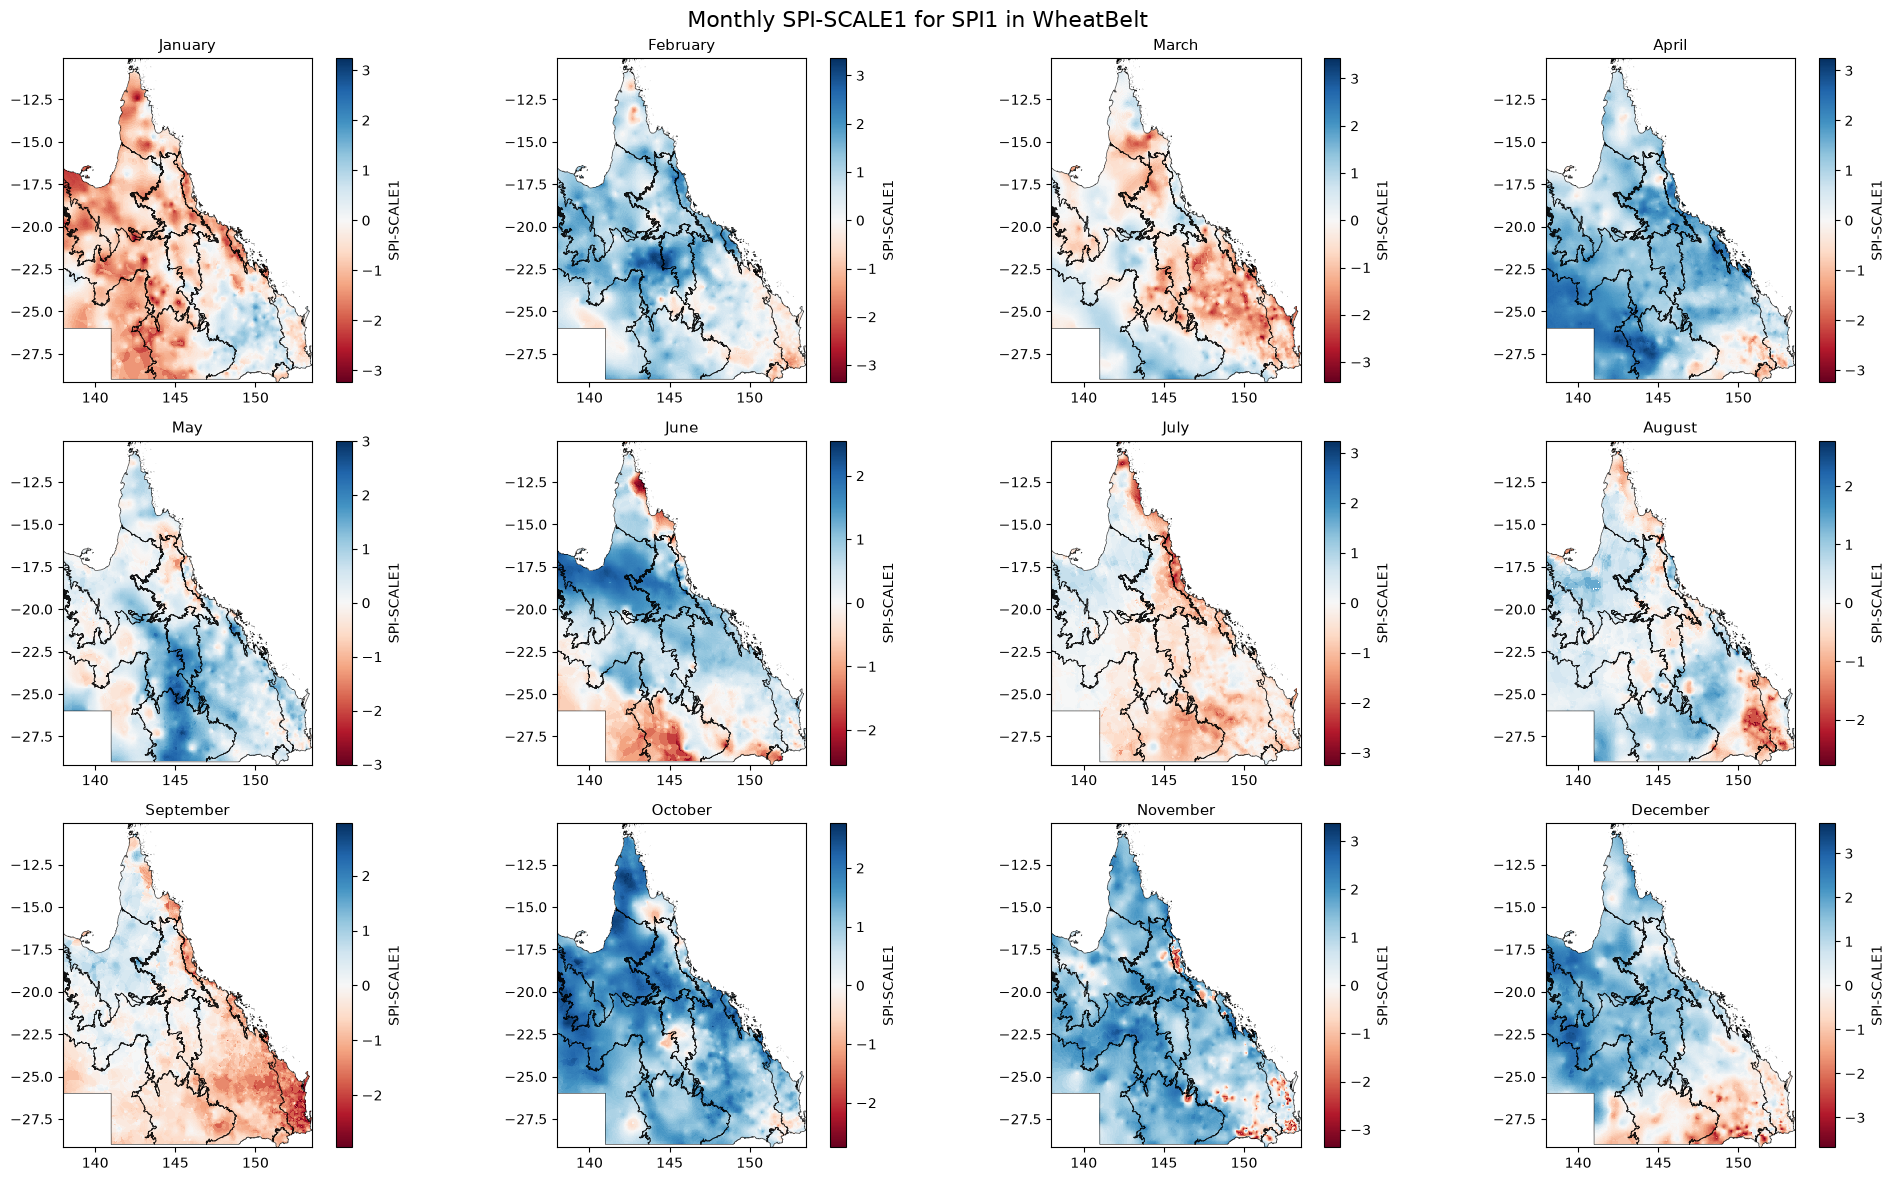

In [4]:
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path

# === Load the shapefile ===
shapefile_path = r'D:\Project Works\Drought_QLD\Data\QLD_BioRegion_Shape_Files\Biogeographic_Regions.shp'
qld_shape = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# === Open the SPI dataset ===
nc_path = Path(r'D:\Project Works\Drought_QLD\Data\SPI\SPI\QLD_SPI1_2000.nc')
year = nc_path.stem.split('_')[1]

ds = xr.open_dataset(nc_path)

# === Select SPI variable ONCE ===
var_name = 'spi_scale1'          # change here: spi_3, spi_6, etc.
monthly_rain = ds[var_name]

# === Convert variable name to display label ===
spi_label = var_name.replace('_', '-').upper()   # spi_1 → SPI-1

# === Fix metadata so colorbar label is correct ===
monthly_rain.attrs.pop('units', None)
monthly_rain.attrs['long_name'] = spi_label

# === Create figure and axes ===
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 12))
axes = axes.flatten()

# === Plot each month ===
for i, month in enumerate(monthly_rain.time):
    ax = axes[i]
    data = monthly_rain.sel(time=month)

    data.plot(
        ax=ax,
        cmap='RdBu',
        add_colorbar=True
    )

    # Overlay region boundaries
    qld_shape.boundary.plot(
        ax=ax,
        color='black',
        linewidth=0.5,
        alpha=0.7
    )

    # Titles and formatting
    ax.set_title(month.dt.strftime('%B').item(), fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')

# === Remove unused subplots ===
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# === Figure title (automatic) ===
plt.suptitle(
    f'Monthly {spi_label} for {year} in WheatBelt',
    fontsize=16,
    y=0.98
)

plt.tight_layout()
plt.show()
